<a href="https://colab.research.google.com/github/AbhyanandSharma2005/AIML-INTERNSHIP-ASSIGNMENTS/blob/main/Adult_Census_Income_Classifucation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Setup and Imports

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn modules for preprocessing, modeling, and evaluation
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

Task 1: Dataset Understanding

--- First 5 rows of the dataset ---


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Dataset Shape: 32561 rows and 15 columns

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB

--- Statistical Summary ---


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000



--- Target Variable Distribution ---
income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


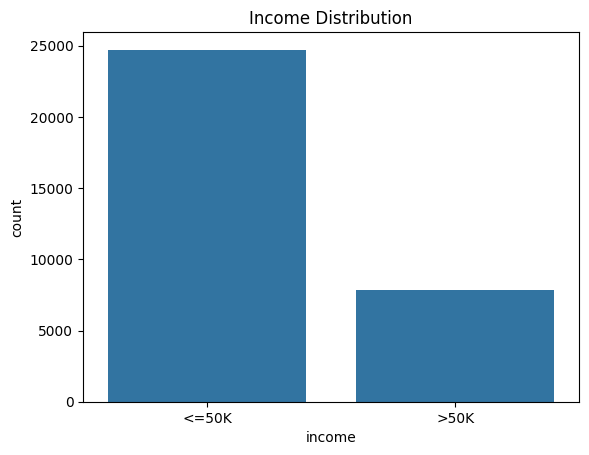

In [ ]:
# --- TASK 1: DATASET UNDERSTANDING (Using Direct URL) ---

# URL to the raw UCI dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

# Define the column names since the raw URL dataset doesn't have a header row
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Read the CSV directly from the URL
# skipinitialspace=True is crucial here because the UCI dataset has spaces before the text (e.g., ' <=50K')
df = pd.read_csv(url, names=columns, skipinitialspace=True)

# 1. Display the first 5 rows
print("--- First 5 rows of the dataset ---")
display(df.head())

# 2. Check the shape of the dataset
print(f"\nDataset Shape: {df.shape[0]} rows and {df.shape[1]} columns")

# 3. Check data types and basic info
print("\n--- Dataset Info ---")
df.info()

# 4. Statistical summary of numerical columns
print("\n--- Statistical Summary ---")
display(df.describe())

# 5. Check the distribution of the Target Variable (Income)
print("\n--- Target Variable Distribution ---")
target_col = 'income'
print(df[target_col].value_counts(normalize=True) * 100)

sns.countplot(x=df[target_col])
plt.title('Income Distribution')
plt.show()

Task 2: Data Cleaning

In [ ]:
# 1. Handle '?' values (often padded with spaces like ' ?')
df = df.replace(r'^\s*\?\s*$', np.nan, regex=True)

# 2. Check for missing values
print("--- Missing values before cleaning ---")
print(df.isnull().sum())

# 3. Impute missing values
# For categorical columns, we impute with the mode (most frequent value)
for col in df.columns:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

print("\n--- Missing values after cleaning ---")
print(df.isnull().sum())

# 4. Handle Duplicate Rows
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

--- Missing values before cleaning ---
age                  0
workclass         1836
fnlwgt               0
education            0
education-num        0
marital-status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     583
income               0
dtype: int64

--- Missing values after cleaning ---
age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
income            0
dtype: int64

Number of duplicate rows found: 24
Duplicates removed.


Task 3: Feature Engineering

In [ ]:
# Separate features (X) and target (y)
X = df.drop(target_col, axis=1)
y = df[target_col]

# 1. Encode Target Variable
# Converts '<=50K' to 0 and '>50K' to 1 (Note: watch out for trailing spaces in the dataset)
le = LabelEncoder()
y = le.fit_transform(y.str.strip())

# 2. Encode Categorical Features
# Using One-Hot Encoding for categorical variables in X
categorical_cols = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# 3. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Feature Scaling (Crucial for KNN, SVM, and Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Shape of X_train: {X_train_scaled.shape}")
print(f"Shape of X_test: {X_test_scaled.shape}")

Shape of X_train: (26029, 97)
Shape of X_test: (6508, 97)


Task 4: Model Building & Task 5: Performance Evaluation

In [ ]:
# Initialize the models
# Note: probability=True is required for SVM to calculate ROC-AUC
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(probability=True, random_state=42)
}

# Dictionary to store the results
results = []

print("Training models... This may take a few minutes (especially SVM and Random Forest).")

for model_name, model in models.items():
    # 1. Train the model
    model.fit(X_train_scaled, y_train)

    # 2. Make predictions
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1] # Get probabilities for ROC-AUC

    # 3. Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)

    # 4. Append to results
    results.append({
        'Algorithm': model_name,
        'Accuracy': round(accuracy, 4),
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1 Score': round(f1, 4),
        'ROC-AUC': round(roc_auc, 4)
    })
    print(f"Finished evaluating {model_name}")

# Convert results into a DataFrame to mimic the requested table
results_df = pd.DataFrame(results)

# Display the final Performance Evaluation Table
print("\n" + "="*60)
print("TASK 5: PERFORMANCE EVALUATION TABLE")
print("="*60)
display(results_df)

Training models... This may take a few minutes (especially SVM and Random Forest).
Finished evaluating Logistic Regression
Finished evaluating Decision Tree
Finished evaluating Random Forest
Finished evaluating KNN
Finished evaluating SVM

TASK 5: PERFORMANCE EVALUATION TABLE


,Algorithm,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8536,0.7425,0.6207,0.6762,0.9062
1,Decision Tree,0.8135,0.6218,0.6195,0.6206,0.7482
2,Random Forest,0.8533,0.7365,0.6294,0.6788,0.9014
3,KNN,0.8256,0.6655,0.5870,0.6238,0.8439
4,SVM,0.8473,0.7494,0.5708,0.6480,0.8930
